# UK House Price Analysis 2024
## A data-driven guide for first-time buyers

This notebook analyses UK Land Registry price paid data to answer two key questions:
1. Which towns and regions are most and least affordable for first-time buyers?
2. Which property types offer the best value?

**Data source:** HM Land Registry Price Paid Data 2024

In [206]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sqlalchemy import create_engine

# Make plots look clean and professional
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (12, 6)

# Connect to our database
engine = create_engine("sqlite:///../data/house_prices.db")

print("Ready!")

Ready!


In [207]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sqlalchemy import create_engine

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (12, 6)

engine = create_engine("sqlite:///../data/house_prices.db")
print("Ready!")

Ready!


In [208]:
df = pd.read_sql("SELECT * FROM transactions", engine)

df["date"] = pd.to_datetime(df["date"])
df["month"] = df["date"].dt.to_period("M")
df["year"] = df["date"].dt.year

print(f"Loaded {len(df):,} rows")

Loaded 105,248 rows


In [209]:
df_clean = df[
    (df["price"] <= 2_000_000) & 
    (df["year"] == 2025)
].copy()

print(f"2025 transactions: {len(df_clean):,}")

2025 transactions: 79,270


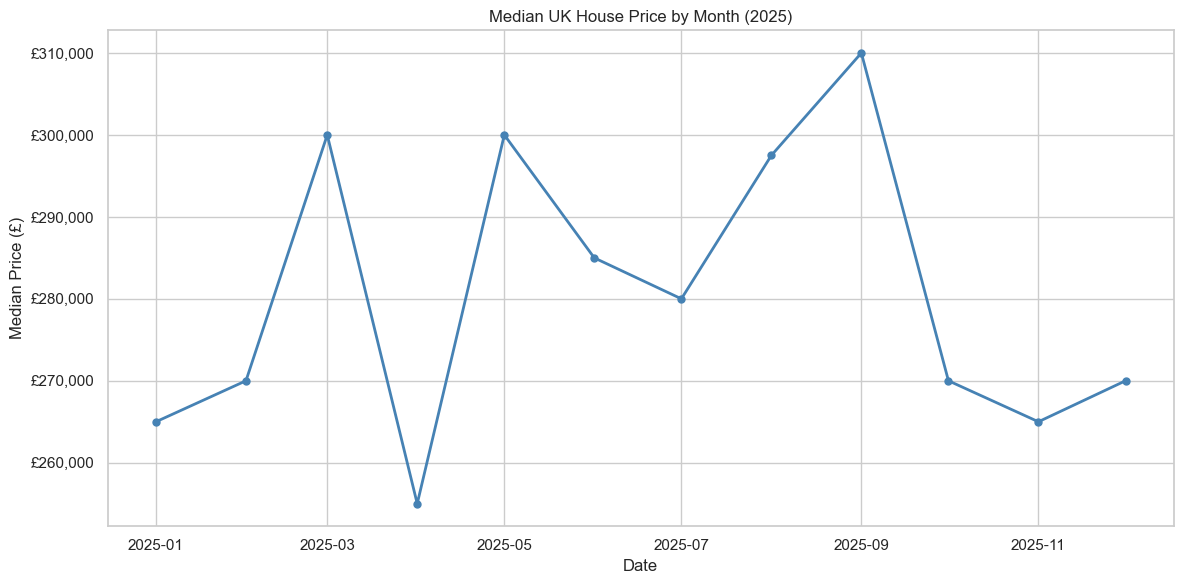

In [210]:
price_over_time = (
    df_clean.groupby("month")["price"]
    .median()
    .reset_index()
)

price_over_time["month"] = price_over_time["month"].dt.to_timestamp()

fig, ax = plt.subplots()

ax.plot(
    price_over_time["month"],
    price_over_time["price"],
    color="steelblue",
    linewidth=2,
    marker="o",
    markersize=5
)

ax.set_xlabel("Date")
ax.set_ylabel("Median Price (£)")
ax.set_title("Median UK House Price by Month (2025)")
ax.yaxis.set_major_formatter(
    plt.FuncFormatter(lambda x, p: f"£{x:,.0f}")
)

plt.tight_layout()
plt.show()

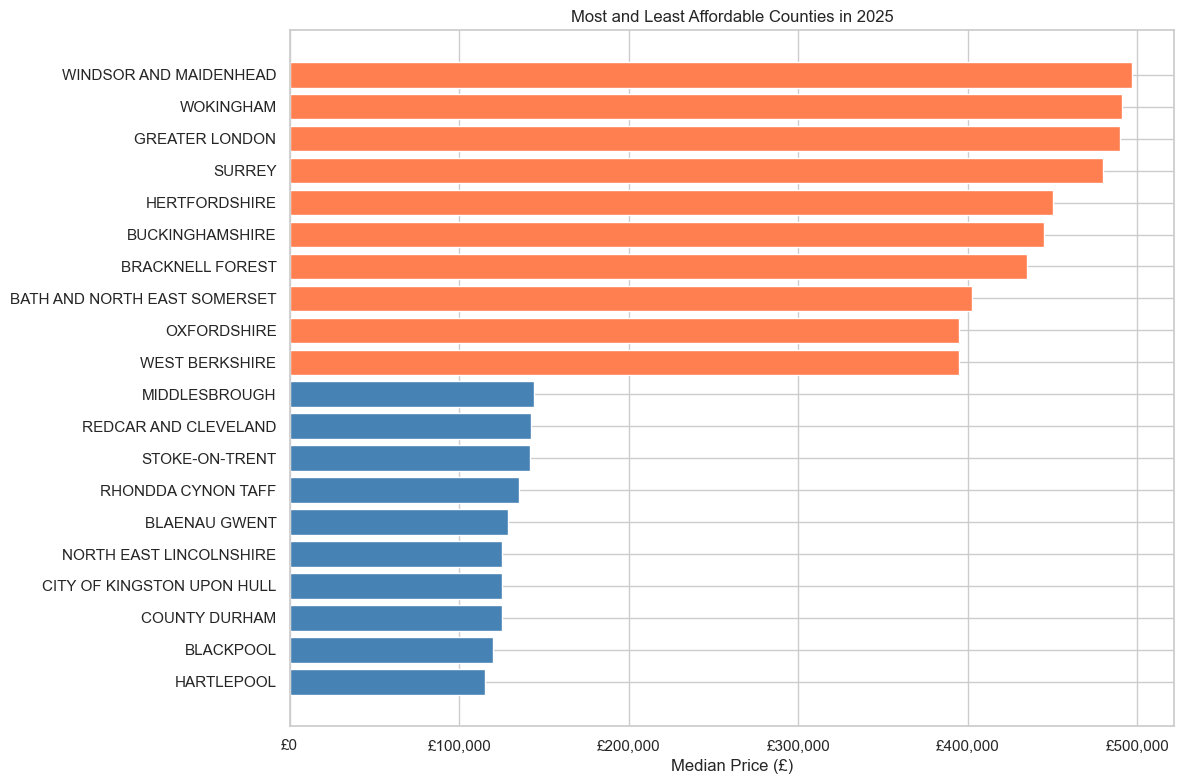

In [211]:
# Median price by county - top 10 most and least affordable
by_county = (
    df_clean.groupby("county")["price"]
    .median()
    .reset_index()
)
by_county.columns = ["county", "median_price"]
by_county = by_county.sort_values("median_price")

# Combine cheapest and most expensive 10
cheapest = by_county.head(10)
expensive = by_county.tail(10)
combined = pd.concat([cheapest, expensive])

fig, ax = plt.subplots(figsize=(12, 8))

colors = ["steelblue"] * 10 + ["coral"] * 10
ax.barh(combined["county"], combined["median_price"], color=colors)

ax.set_xlabel("Median Price (£)")
ax.set_title("Most and Least Affordable Counties in 2025")
ax.xaxis.set_major_formatter(
    plt.FuncFormatter(lambda x, p: f"£{x:,.0f}")
)

plt.tight_layout()
plt.show()

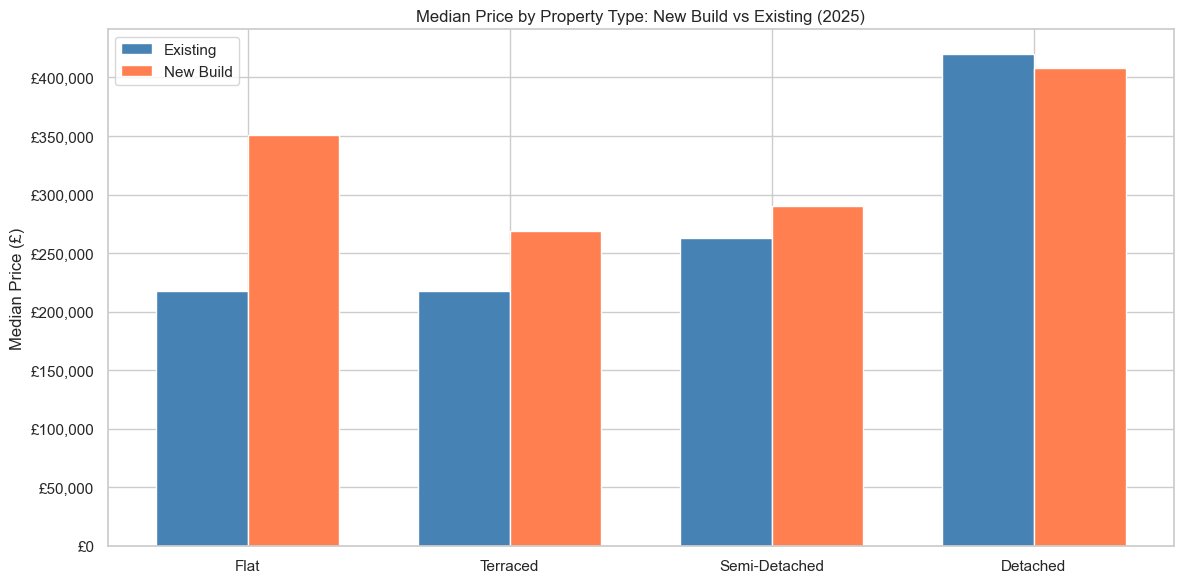

In [212]:
import numpy as np

fig, ax = plt.subplots(figsize=(12, 6))

plot_data = by_property[by_property["property_type"] != "O"].copy()

# Fix the labels directly here
plot_data["new_build"] = plot_data["new_build"].map({"N": "Existing", "Y": "New Build"})

property_types = ["F", "T", "S", "D"]
x = np.arange(len(property_types))
width = 0.35

existing = plot_data[plot_data["new_build"] == "Existing"].set_index("property_type")
new_build = plot_data[plot_data["new_build"] == "New Build"].set_index("property_type")

ax.bar(x - width/2,
       [existing.loc[p, "median_price"] for p in property_types],
       width, label="Existing", color="steelblue")

ax.bar(x + width/2,
       [new_build.loc[p, "median_price"] for p in property_types],
       width, label="New Build", color="coral")

ax.set_xticks(x)
ax.set_xticklabels(["Flat", "Terraced", "Semi-Detached", "Detached"])
ax.set_ylabel("Median Price (£)")
ax.set_title("Median Price by Property Type: New Build vs Existing (2025)")
ax.legend()
ax.yaxis.set_major_formatter(
    plt.FuncFormatter(lambda x, p: f"£{x:,.0f}")
)

plt.tight_layout()
plt.show()